# Klasifikasi Sentimen Berbasis Aspek (ABSA) pada Ulasan Wisata Alam Kabupaten Bandung Barat

## Data Preparation (CRISP-DM)

In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

---
## Tahap 1: Data Exploration

In [5]:
df = pd.read_csv('Panduan Tubes/tourist_reviews.csv')

print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"Kolom: {list(df.columns)}")
print()
print(df.dtypes)
print()
df.head()

Jumlah baris: 11620
Jumlah kolom: 8
Kolom: ['id', 'datetime', 'location', 'text', 'rating', 'accessibility', 'facility', 'activity']

id               object
datetime         object
location         object
text             object
rating            int64
accessibility    object
facility         object
activity         object
dtype: object



,id,datetime,location,text,rating,accessibility,facility,activity
0,47d0cdd937754bd6b860f89b2bab1dbb,2022-05-15 11:58:43,Curug Malela,Akses jalannya waktu itu masih sulit di jangka...,4,negative,neutral,neutral
1,4804acd6c05e4f89b098e2ca35019419,2022-08-15 11:58:43,Curug Malela,"Perjalanan yg bnr"" bikin Syahduu ,, dr Tempat ...",5,neutral,neutral,positive
2,3eae265bf32a45eca31765a4145bc030,2022-03-15 11:58:43,Curug Malela,"Minggu 13 februari 2022 ,\n\ngas santai pakai ...",5,positive,negative,positive
3,61037dbdb7b14045be49d4494e95cf05,2022-05-15 11:58:44,Curug Malela,7 mei 2022\nTouring bari mudik\nMntap perjalan...,5,positive,neutral,positive
4,a2c9e817e2b949c6880f971f43a11d2f,2022-08-15 11:58:44,Curug Malela,Perjalanan touring motor dari bekasi melewati ...,5,neutral,neutral,positive


In [6]:
print("--- Statistik Deskriptif ---")
df.describe(include='all')

--- Statistik Deskriptif ---


,id,datetime,location,text,rating,accessibility,facility,activity
count,11620,11620,11620,11620,11620.000000,11620,11620,11620
unique,11620,5828,25,11620,NaN,3,3,3
top,47d0cdd937754bd6b860f89b2bab1dbb,2021-02-15 11:58:47,Sarae Hills,Akses jalannya waktu itu masih sulit di jangka...,NaN,neutral,neutral,positive
freq,1,11,952,1,NaN,10197,8105,7153
mean,NaN,NaN,NaN,NaN,4.502582,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,0.833755,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN


In [7]:
print("--- Jumlah Missing Values ---")
print(df.isnull().sum())
print()
print(f"Baris duplikat: {df.duplicated().sum()}")

--- Jumlah Missing Values ---
id               0
datetime         0
location         0
text             0
rating           0
accessibility    0
facility         0
activity         0
dtype: int64

Baris duplikat: 0


In [8]:
target_cols = ['accessibility', 'facility', 'activity']

for col in target_cols:
    print(f"\nDistribusi '{col}':")
    dist = df[col].value_counts()
    print(dist)
    total = dist.sum()
    for label, count in dist.items():
        print(f"  {label}: {count / total * 100:.2f}%")


Distribusi 'accessibility':
accessibility
neutral     10197
negative      862
positive      561
Name: count, dtype: int64
  neutral: 87.75%
  negative: 7.42%
  positive: 4.83%

Distribusi 'facility':
facility
neutral     8105
positive    2318
negative    1197
Name: count, dtype: int64
  neutral: 69.75%
  positive: 19.95%
  negative: 10.30%

Distribusi 'activity':
activity
positive    7153
neutral     4084
negative     383
Name: count, dtype: int64
  positive: 61.56%
  neutral: 35.15%
  negative: 3.30%


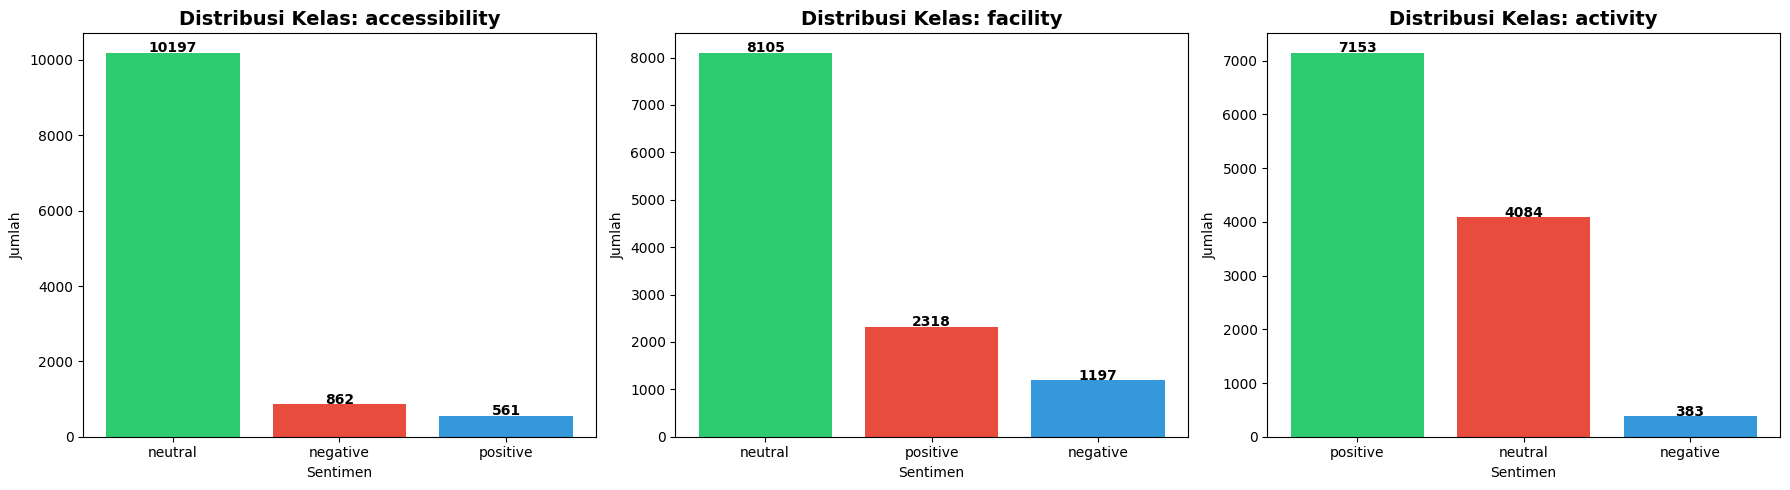

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db']

for i, col in enumerate(target_cols):
    dist = df[col].value_counts()
    axes[i].bar(dist.index, dist.values, color=colors)
    axes[i].set_title(f'Distribusi Kelas: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Sentimen')
    axes[i].set_ylabel('Jumlah')
    for j, v in enumerate(dist.values):
        axes[i].text(j, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print("--- Identifikasi Imbalanced Data ---")
for col in target_cols:
    dist = df[col].value_counts()
    ratio = dist.min() / dist.max()
    print(f"\n{col}:")
    print(f"  Kelas mayoritas: {dist.idxmax()} ({dist.max()})")
    print(f"  Kelas minoritas: {dist.idxmin()} ({dist.min()})")
    print(f"  Rasio min/max: {ratio:.4f}")
    if ratio < 0.5:
        print(f"  Status: IMBALANCED (rasio < 0.5)")
    else:
        print(f"  Status: BALANCED (rasio >= 0.5)")

--- Identifikasi Imbalanced Data ---

accessibility:
  Kelas mayoritas: neutral (10197)
  Kelas minoritas: positive (561)
  Rasio min/max: 0.0550
  Status: IMBALANCED (rasio < 0.5)

facility:
  Kelas mayoritas: neutral (8105)
  Kelas minoritas: negative (1197)
  Rasio min/max: 0.1477
  Status: IMBALANCED (rasio < 0.5)

activity:
  Kelas mayoritas: positive (7153)
  Kelas minoritas: negative (383)
  Rasio min/max: 0.0535
  Status: IMBALANCED (rasio < 0.5)


---
## Tahap 2: Data Cleansing

In [11]:
print(f"Jumlah data sebelum cleansing: {df.shape[0]}")

df_clean = df.copy()

before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after = df_clean.shape[0]
print(f"Baris duplikat dihapus: {before - after}")

before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=['text'] + target_cols)
after = df_clean.shape[0]
print(f"Baris kosong dihapus: {before - after}")

print(f"Jumlah data setelah hapus duplikat & kosong: {df_clean.shape[0]}")

Jumlah data sebelum cleansing: 11620
Baris duplikat dihapus: 0
Baris kosong dihapus: 0
Jumlah data setelah hapus duplikat & kosong: 11620


In [12]:
df_clean['text_clean'] = df_clean['text'].astype(str).str.lower()
print("Case folding selesai.")
print(f"Contoh: '{df_clean['text'].iloc[0][:80]}...'")
print(f"     -> '{df_clean['text_clean'].iloc[0][:80]}...'")

Case folding selesai.
Contoh: 'Akses jalannya waktu itu masih sulit di jangkau, perjalanan menuji curug lumayan...'
     -> 'akses jalannya waktu itu masih sulit di jangkau, perjalanan menuji curug lumayan...'


In [13]:
def clean_text(text):
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['text_clean'] = df_clean['text_clean'].apply(clean_text)
print("Pembersihan URL, mention, hashtag, tanda baca, dan angka selesai.")
print(f"Contoh hasil: '{df_clean['text_clean'].iloc[0][:100]}...'")

Pembersihan URL, mention, hashtag, tanda baca, dan angka selesai.
Contoh hasil: 'akses jalannya waktu itu masih sulit di jangkau perjalanan menuji curug lumayan jauh...'


In [14]:
stop_factory = StopWordRemoverFactory()
stopword_remover = stop_factory.create_stop_word_remover()
stopwords_list = stop_factory.get_stop_words()
print(f"Jumlah stopword Sastrawi: {len(stopwords_list)}")

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stopwords_list]
    return ' '.join(filtered)

df_clean['text_clean'] = df_clean['text_clean'].apply(remove_stopwords)
print("Stopword removal selesai.")
print(f"Contoh hasil: '{df_clean['text_clean'].iloc[0][:100]}...'")

Jumlah stopword Sastrawi: 126
Stopword removal selesai.
Contoh hasil: 'akses jalannya waktu sulit jangkau perjalanan menuji curug lumayan jauh...'


In [15]:
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def stem_text(text):
    return stemmer.stem(text)

print("Proses stemming sedang berjalan (ini membutuhkan waktu)...")
df_clean['text_clean'] = df_clean['text_clean'].apply(stem_text)
print("Stemming selesai.")
print(f"Contoh hasil: '{df_clean['text_clean'].iloc[0][:100]}...'")

Proses stemming sedang berjalan (ini membutuhkan waktu)...
Stemming selesai.
Contoh hasil: 'akses jalan waktu sulit jangkau jalan tuji curug lumayan jauh...'


In [16]:
before = df_clean.shape[0]
df_clean = df_clean[df_clean['text_clean'].str.strip().astype(bool)]
after = df_clean.shape[0]
print(f"Baris dengan teks kosong dihapus: {before - after}")
print(f"Jumlah data setelah cleansing: {df_clean.shape[0]}")

Baris dengan teks kosong dihapus: 10
Jumlah data setelah cleansing: 11610


In [17]:
print("--- Perbandingan Sebelum dan Sesudah Cleansing ---")
sample_indices = df_clean.index[:3]
for idx in sample_indices:
    print(f"\nBaris {idx}:")
    print(f"  Sebelum: {df_clean.loc[idx, 'text'][:100]}...")
    print(f"  Sesudah: {df_clean.loc[idx, 'text_clean'][:100]}...")

df_clean.to_csv('tourist_reviews_cleaned.csv', index=False)
print("\nData bersih disimpan sebagai 'tourist_reviews_cleaned.csv'")

--- Perbandingan Sebelum dan Sesudah Cleansing ---

Baris 0:
  Sebelum: Akses jalannya waktu itu masih sulit di jangkau, perjalanan menuji curug lumayan jauh...
  Sesudah: akses jalan waktu sulit jangkau jalan tuji curug lumayan jauh...

Baris 1:
  Sebelum: Perjalanan yg bnr" bikin Syahduu ,, dr Tempat parkir ke lokasi Curug ,,
Lelahh pun terasa hilang ket...
  Sesudah: jalan yg bnr bikin syahduu dr tempat parkir lokasi curug lelahh asa hilang sampe lokasi...

Baris 2:
  Sebelum: Minggu 13 februari 2022 ,

gas santai pakai motor dari dago jam 6:00 sampe parkiran curug jam 9 lebi...
  Sesudah: minggu februari gas santai pakai motor dago jam sampe parkir curug jam lebih disasarin gps gunung ha...

Data bersih disimpan sebagai 'tourist_reviews_cleaned.csv'


---
## Tahap 3: Data Transformation

In [18]:
print("--- Label Encoding ---")
label_encoders = {}
df_transformed = df_clean.copy()

for col in target_cols:
    le = LabelEncoder()
    df_transformed[f'{col}_encoded'] = le.fit_transform(df_transformed[col])
    label_encoders[col] = le
    print(f"\n{col}:")
    for i, label in enumerate(le.classes_):
        print(f"  {label} -> {i}")

--- Label Encoding ---

accessibility:
  negative -> 0
  neutral -> 1
  positive -> 2

facility:
  negative -> 0
  neutral -> 1
  positive -> 2

activity:
  negative -> 0
  neutral -> 1
  positive -> 2


In [19]:
print("--- Ekstraksi Fitur dengan TF-IDF ---")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df_transformed['text_clean'])
print(f"Dimensi matriks TF-IDF: {X_tfidf.shape}")
print(f"Jumlah fitur (kata unik): {len(tfidf_vectorizer.get_feature_names_out())}")

top_n = 20
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_mean = X_tfidf.mean(axis=0).A1
top_indices = tfidf_mean.argsort()[-top_n:][::-1]
print(f"\nTop {top_n} kata berdasarkan rata-rata TF-IDF:")
for rank, idx in enumerate(top_indices, 1):
    print(f"  {rank}. {feature_names[idx]}: {tfidf_mean[idx]:.6f}")

--- Ekstraksi Fitur dengan TF-IDF ---
Dimensi matriks TF-IDF: (11610, 5000)
Jumlah fitur (kata unik): 5000

Top 20 kata berdasarkan rata-rata TF-IDF:
  1. tempat: 0.057948
  2. bagus: 0.043205
  3. nya: 0.033028
  4. yg: 0.032201
  5. buat: 0.031702
  6. banyak: 0.025930
  7. jalan: 0.024557
  8. indah: 0.023959
  9. sangat: 0.023884
  10. foto: 0.023486
  11. wisata: 0.022545
  12. pandang: 0.020827
  13. cocok: 0.020738
  14. masuk: 0.020612
  15. sejuk: 0.020521
  16. banget: 0.018876
  17. keluarga: 0.018441
  18. tiket: 0.017512
  19. nyaman: 0.017376
  20. alam: 0.017070


In [20]:
print("--- SMOTE untuk Menangani Imbalanced Data ---")
smote = SMOTE(random_state=42)

X_resampled = {}
y_resampled = {}

for col in target_cols:
    y = df_transformed[f'{col}_encoded'].values
    print(f"\n{'=' * 40}")
    print(f"SMOTE untuk target: {col}")
    print(f"{'=' * 40}")
    
    print(f"\nDistribusi SEBELUM SMOTE:")
    unique, counts = np.unique(y, return_counts=True)
    for u, c in zip(unique, counts):
        original_label = label_encoders[col].inverse_transform([u])[0]
        print(f"  {original_label} ({u}): {c}")
    
    X_res, y_res = smote.fit_resample(X_tfidf, y)
    
    X_resampled[col] = X_res
    y_resampled[col] = y_res
    
    print(f"\nDistribusi SESUDAH SMOTE:")
    unique, counts = np.unique(y_res, return_counts=True)
    for u, c in zip(unique, counts):
        original_label = label_encoders[col].inverse_transform([u])[0]
        print(f"  {original_label} ({u}): {c}")
    
    print(f"\nUkuran data: {X_tfidf.shape[0]} -> {X_res.shape[0]}")

--- SMOTE untuk Menangani Imbalanced Data ---

SMOTE untuk target: accessibility

Distribusi SEBELUM SMOTE:
  negative (0): 862
  neutral (1): 10187
  positive (2): 561

Distribusi SESUDAH SMOTE:
  negative (0): 10187
  neutral (1): 10187
  positive (2): 10187

Ukuran data: 11610 -> 30561

SMOTE untuk target: facility

Distribusi SEBELUM SMOTE:
  negative (0): 1197
  neutral (1): 8095
  positive (2): 2318

Distribusi SESUDAH SMOTE:
  negative (0): 8095
  neutral (1): 8095
  positive (2): 8095

Ukuran data: 11610 -> 24285

SMOTE untuk target: activity

Distribusi SEBELUM SMOTE:
  negative (0): 383
  neutral (1): 4074
  positive (2): 7153

Distribusi SESUDAH SMOTE:
  negative (0): 7153
  neutral (1): 7153
  positive (2): 7153

Ukuran data: 11610 -> 21459


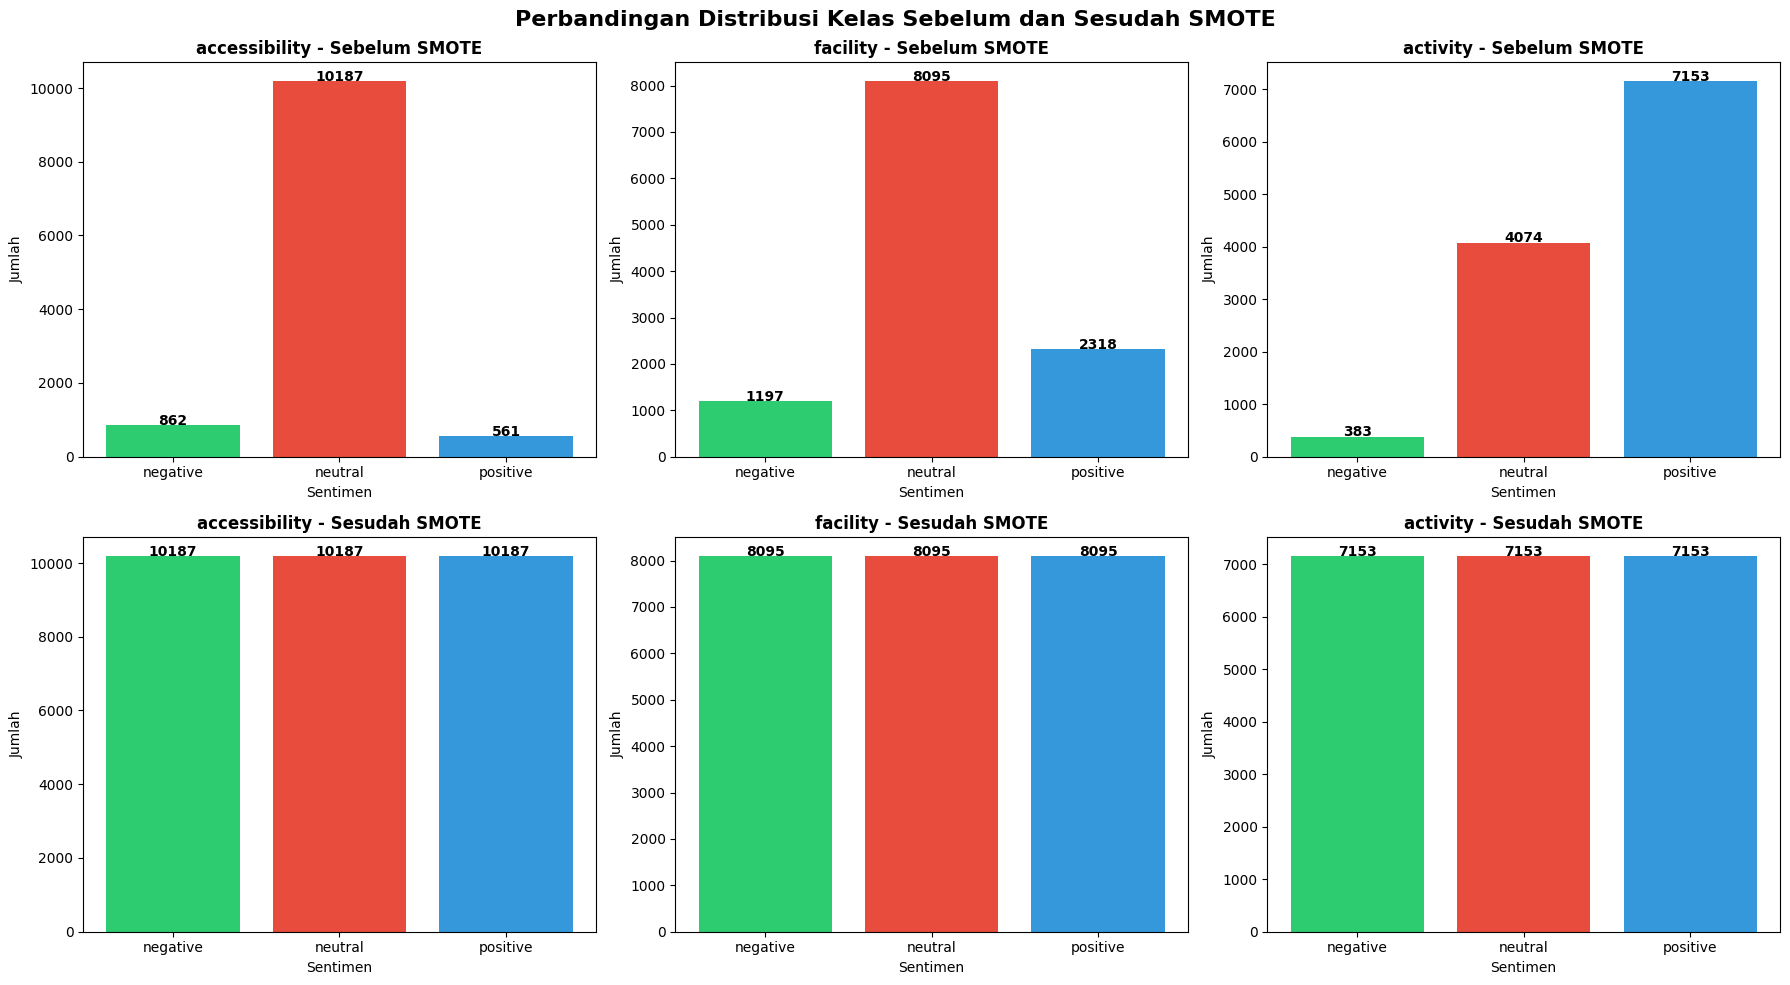

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(target_cols):
    y_before = df_transformed[f'{col}_encoded'].values
    y_after = y_resampled[col]
    
    labels_before = label_encoders[col].inverse_transform(np.unique(y_before))
    counts_before = [np.sum(y_before == v) for v in np.unique(y_before)]
    
    labels_after = label_encoders[col].inverse_transform(np.unique(y_after))
    counts_after = [np.sum(y_after == v) for v in np.unique(y_after)]
    
    axes[0][i].bar(labels_before, counts_before, color=colors)
    axes[0][i].set_title(f'{col} - Sebelum SMOTE', fontsize=12, fontweight='bold')
    axes[0][i].set_xlabel('Sentimen')
    axes[0][i].set_ylabel('Jumlah')
    for j, v in enumerate(counts_before):
        axes[0][i].text(j, v + 10, str(v), ha='center', fontweight='bold')
    
    axes[1][i].bar(labels_after, counts_after, color=colors)
    axes[1][i].set_title(f'{col} - Sesudah SMOTE', fontsize=12, fontweight='bold')
    axes[1][i].set_xlabel('Sentimen')
    axes[1][i].set_ylabel('Jumlah')
    for j, v in enumerate(counts_after):
        axes[1][i].text(j, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Perbandingan Distribusi Kelas Sebelum dan Sesudah SMOTE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_smote.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print("=" * 60)
print("RINGKASAN DATA PREPARATION")
print("=" * 60)
print(f"Jumlah data awal: {df.shape[0]}")
print(f"Jumlah data setelah cleansing: {df_clean.shape[0]}")
print(f"Jumlah fitur TF-IDF: {X_tfidf.shape[1]}")
for col in target_cols:
    print(f"Jumlah data setelah SMOTE ({col}): {X_resampled[col].shape[0]}")
print(f"\nFile output:")
print(f"  - tourist_reviews_cleaned.csv")
print(f"  - distribusi_kelas.png")
print(f"  - distribusi_smote.png")

RINGKASAN DATA PREPARATION
Jumlah data awal: 11620
Jumlah data setelah cleansing: 11610
Jumlah fitur TF-IDF: 5000
Jumlah data setelah SMOTE (accessibility): 30561
Jumlah data setelah SMOTE (facility): 24285
Jumlah data setelah SMOTE (activity): 21459

File output:
  - tourist_reviews_cleaned.csv
  - distribusi_kelas.png
  - distribusi_smote.png


---
---
# Modeling Fase 1: Supervised Learning

Model yang digunakan: **Logistic Regression** dan **Naïve Bayes Classifier**

Proses:
1. Train-Test Split (80:20)
2. Training model baseline
3. Hyperparameter Tuning (GridSearchCV)
4. Evaluasi (Confusion Matrix & F1-Score)

In [23]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

### 1. Train-Test Split (80:20)

In [24]:
split_data = {}

for col in target_cols:
    X = X_resampled[col]
    y = y_resampled[col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    split_data[col] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }
    
    print(f"\n{col}:")
    print(f"  Total data (setelah SMOTE): {X.shape[0]}")
    print(f"  Data latih: {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
    print(f"  Data uji  : {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
    print(f"  Distribusi y_train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"  Distribusi y_test : {dict(zip(*np.unique(y_test, return_counts=True)))}")


accessibility:
  Total data (setelah SMOTE): 30561
  Data latih: 24448 (80.0%)
  Data uji  : 6113 (20.0%)
  Distribusi y_train: {np.int64(0): np.int64(8150), np.int64(1): np.int64(8149), np.int64(2): np.int64(8149)}
  Distribusi y_test : {np.int64(0): np.int64(2037), np.int64(1): np.int64(2038), np.int64(2): np.int64(2038)}

facility:
  Total data (setelah SMOTE): 24285
  Data latih: 19428 (80.0%)
  Data uji  : 4857 (20.0%)
  Distribusi y_train: {np.int64(0): np.int64(6476), np.int64(1): np.int64(6476), np.int64(2): np.int64(6476)}
  Distribusi y_test : {np.int64(0): np.int64(1619), np.int64(1): np.int64(1619), np.int64(2): np.int64(1619)}

activity:
  Total data (setelah SMOTE): 21459
  Data latih: 17167 (80.0%)
  Data uji  : 4292 (20.0%)
  Distribusi y_train: {np.int64(0): np.int64(5723), np.int64(1): np.int64(5722), np.int64(2): np.int64(5722)}
  Distribusi y_test : {np.int64(0): np.int64(1430), np.int64(1): np.int64(1431), np.int64(2): np.int64(1431)}


### 2. Training Model Baseline (Sebelum Tuning)

In [25]:
baseline_results = {}

for col in target_cols:
    print("=" * 60)
    print(f"TARGET: {col.upper()}")
    print("=" * 60)
    
    X_train = split_data[col]['X_train']
    X_test = split_data[col]['X_test']
    y_train = split_data[col]['y_train']
    y_test = split_data[col]['y_test']
    
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    
    print("\n--- Logistic Regression (Baseline) ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
    print(f"F1-Score (weighted): {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
    print()
    target_names = label_encoders[col].classes_
    print(classification_report(y_test, y_pred_lr, target_names=target_names))
    
    nb = MultinomialNB()
    nb.fit(X_train, y_train)
    y_pred_nb = nb.predict(X_test)
    
    print("--- Naïve Bayes (Baseline) ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
    print(f"F1-Score (weighted): {f1_score(y_test, y_pred_nb, average='weighted'):.4f}")
    print()
    print(classification_report(y_test, y_pred_nb, target_names=target_names))
    
    baseline_results[col] = {
        'lr_f1': f1_score(y_test, y_pred_lr, average='weighted'),
        'nb_f1': f1_score(y_test, y_pred_nb, average='weighted'),
        'lr_acc': accuracy_score(y_test, y_pred_lr),
        'nb_acc': accuracy_score(y_test, y_pred_nb)
    }

TARGET: ACCESSIBILITY

--- Logistic Regression (Baseline) ---
Accuracy: 0.9333
F1-Score (weighted): 0.9331

              precision    recall  f1-score   support

    negative       0.93      0.92      0.93      2037
     neutral       0.92      0.91      0.91      2038
    positive       0.95      0.97      0.96      2038

    accuracy                           0.93      6113
   macro avg       0.93      0.93      0.93      6113
weighted avg       0.93      0.93      0.93      6113

--- Naïve Bayes (Baseline) ---
Accuracy: 0.8690
F1-Score (weighted): 0.8669

              precision    recall  f1-score   support

    negative       0.86      0.94      0.89      2037
     neutral       0.92      0.74      0.82      2038
    positive       0.84      0.93      0.88      2038

    accuracy                           0.87      6113
   macro avg       0.87      0.87      0.87      6113
weighted avg       0.87      0.87      0.87      6113

TARGET: FACILITY

--- Logistic Regression (Baseline) 

### 3. Hyperparameter Tuning dengan GridSearchCV

In [26]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'penalty': ['l2']
}

nb_param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

best_models = {}
tuning_results = {}

for col in target_cols:
    print("=" * 60)
    print(f"HYPERPARAMETER TUNING: {col.upper()}")
    print("=" * 60)
    
    X_train = split_data[col]['X_train']
    X_test = split_data[col]['X_test']
    y_train = split_data[col]['y_train']
    y_test = split_data[col]['y_test']
    
    print("\nTuning Logistic Regression...")
    lr_grid = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        lr_param_grid,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=0
    )
    lr_grid.fit(X_train, y_train)
    
    print(f"Best Parameters: {lr_grid.best_params_}")
    print(f"Best CV F1-Score: {lr_grid.best_score_:.4f}")
    
    y_pred_lr_tuned = lr_grid.best_estimator_.predict(X_test)
    lr_tuned_f1 = f1_score(y_test, y_pred_lr_tuned, average='weighted')
    lr_tuned_acc = accuracy_score(y_test, y_pred_lr_tuned)
    print(f"Test Accuracy: {lr_tuned_acc:.4f}")
    print(f"Test F1-Score (weighted): {lr_tuned_f1:.4f}")
    
    print("\nTuning Naïve Bayes...")
    nb_grid = GridSearchCV(
        MultinomialNB(),
        nb_param_grid,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=0
    )
    nb_grid.fit(X_train, y_train)
    
    print(f"Best Parameters: {nb_grid.best_params_}")
    print(f"Best CV F1-Score: {nb_grid.best_score_:.4f}")
    
    y_pred_nb_tuned = nb_grid.best_estimator_.predict(X_test)
    nb_tuned_f1 = f1_score(y_test, y_pred_nb_tuned, average='weighted')
    nb_tuned_acc = accuracy_score(y_test, y_pred_nb_tuned)
    print(f"Test Accuracy: {nb_tuned_acc:.4f}")
    print(f"Test F1-Score (weighted): {nb_tuned_f1:.4f}")
    
    best_models[col] = {
        'lr': lr_grid.best_estimator_,
        'nb': nb_grid.best_estimator_,
        'lr_pred': y_pred_lr_tuned,
        'nb_pred': y_pred_nb_tuned
    }
    
    tuning_results[col] = {
        'lr_f1': lr_tuned_f1,
        'nb_f1': nb_tuned_f1,
        'lr_acc': lr_tuned_acc,
        'nb_acc': nb_tuned_acc,
        'lr_params': lr_grid.best_params_,
        'nb_params': nb_grid.best_params_
    }

HYPERPARAMETER TUNING: ACCESSIBILITY

Tuning Logistic Regression...
Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-Score: 0.9534
Test Accuracy: 0.9602
Test F1-Score (weighted): 0.9597

Tuning Naïve Bayes...
Best Parameters: {'alpha': 0.01}
Best CV F1-Score: 0.8941
Test Accuracy: 0.8963
Test F1-Score (weighted): 0.8950
HYPERPARAMETER TUNING: FACILITY

Tuning Logistic Regression...
Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1-Score: 0.8719
Test Accuracy: 0.8763
Test F1-Score (weighted): 0.8736

Tuning Naïve Bayes...
Best Parameters: {'alpha': 0.01}
Best CV F1-Score: 0.8042
Test Accuracy: 0.8073
Test F1-Score (weighted): 0.8041
HYPERPARAMETER TUNING: ACTIVITY

Tuning Logistic Regression...
Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'saga'}
Best CV F1-Score: 0.7992
Test Accuracy: 0.8057
Test F1-Score (weighted): 0.8049

Tuning Naïve Bayes...
Best Parameters: {'alpha': 0.01}
Best CV F1-Score: 0.7408
Test Accuracy: 0.74

### 4. Evaluasi: Confusion Matrix

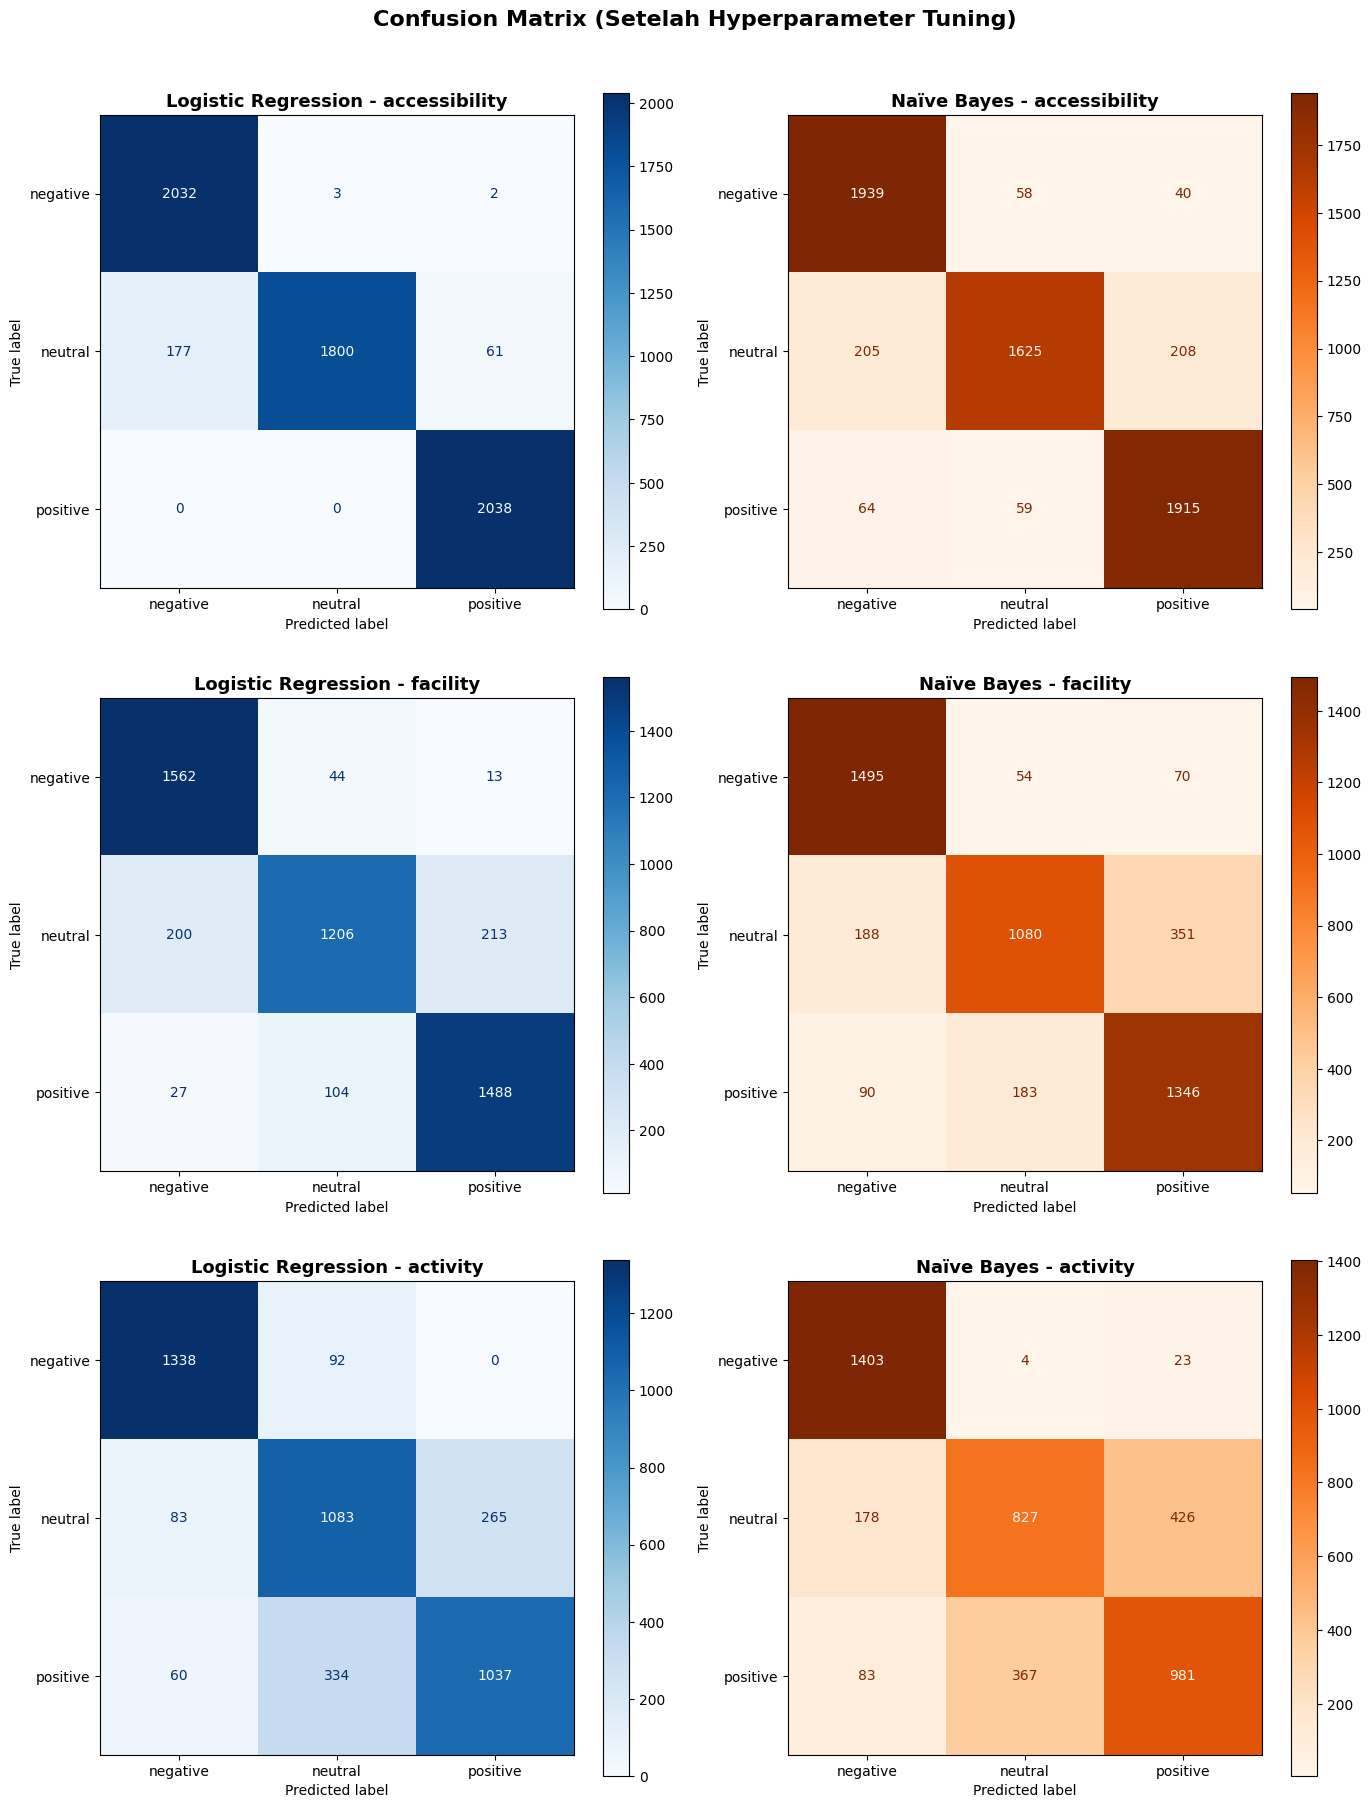

Confusion matrix disimpan sebagai 'confusion_matrix.png'


In [27]:
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

for i, col in enumerate(target_cols):
    y_test = split_data[col]['y_test']
    target_names = label_encoders[col].classes_
    
    cm_lr = confusion_matrix(y_test, best_models[col]['lr_pred'])
    disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=target_names)
    disp_lr.plot(ax=axes[i][0], cmap='Blues', values_format='d')
    axes[i][0].set_title(f'Logistic Regression - {col}', fontsize=13, fontweight='bold')
    
    cm_nb = confusion_matrix(y_test, best_models[col]['nb_pred'])
    disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=target_names)
    disp_nb.plot(ax=axes[i][1], cmap='Oranges', values_format='d')
    axes[i][1].set_title(f'Naïve Bayes - {col}', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix (Setelah Hyperparameter Tuning)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix disimpan sebagai 'confusion_matrix.png'")

In [28]:
for col in target_cols:
    y_test = split_data[col]['y_test']
    target_names = label_encoders[col].classes_
    
    print("=" * 60)
    print(f"CLASSIFICATION REPORT (TUNED): {col.upper()}")
    print("=" * 60)
    
    print("\n--- Logistic Regression ---")
    print(classification_report(y_test, best_models[col]['lr_pred'], target_names=target_names))
    
    print("--- Naïve Bayes ---")
    print(classification_report(y_test, best_models[col]['nb_pred'], target_names=target_names))

CLASSIFICATION REPORT (TUNED): ACCESSIBILITY

--- Logistic Regression ---
              precision    recall  f1-score   support

    negative       0.92      1.00      0.96      2037
     neutral       1.00      0.88      0.94      2038
    positive       0.97      1.00      0.98      2038

    accuracy                           0.96      6113
   macro avg       0.96      0.96      0.96      6113
weighted avg       0.96      0.96      0.96      6113

--- Naïve Bayes ---
              precision    recall  f1-score   support

    negative       0.88      0.95      0.91      2037
     neutral       0.93      0.80      0.86      2038
    positive       0.89      0.94      0.91      2038

    accuracy                           0.90      6113
   macro avg       0.90      0.90      0.90      6113
weighted avg       0.90      0.90      0.90      6113

CLASSIFICATION REPORT (TUNED): FACILITY

--- Logistic Regression ---
              precision    recall  f1-score   support

    negative       0

### 5. Perbandingan F1-Score & Penentuan Model Terbaik

In [29]:
comparison_data = []

for col in target_cols:
    comparison_data.append({
        'Aspek': col,
        'LR Baseline F1': baseline_results[col]['lr_f1'],
        'LR Tuned F1': tuning_results[col]['lr_f1'],
        'NB Baseline F1': baseline_results[col]['nb_f1'],
        'NB Tuned F1': tuning_results[col]['nb_f1'],
        'LR Tuned Acc': tuning_results[col]['lr_acc'],
        'NB Tuned Acc': tuning_results[col]['nb_acc']
    })

df_comparison = pd.DataFrame(comparison_data)

for c in df_comparison.columns[1:]:
    df_comparison[c] = df_comparison[c].map('{:.4f}'.format)

print("--- Tabel Perbandingan Performa ---")
print(df_comparison.to_string(index=False))

--- Tabel Perbandingan Performa ---
        Aspek LR Baseline F1 LR Tuned F1 NB Baseline F1 NB Tuned F1 LR Tuned Acc NB Tuned Acc
accessibility         0.9331      0.9597         0.8669      0.8950       0.9602       0.8963
     facility         0.8513      0.8736         0.7884      0.8041       0.8763       0.8073
     activity         0.7895      0.8049         0.7196      0.7406       0.8057       0.7481


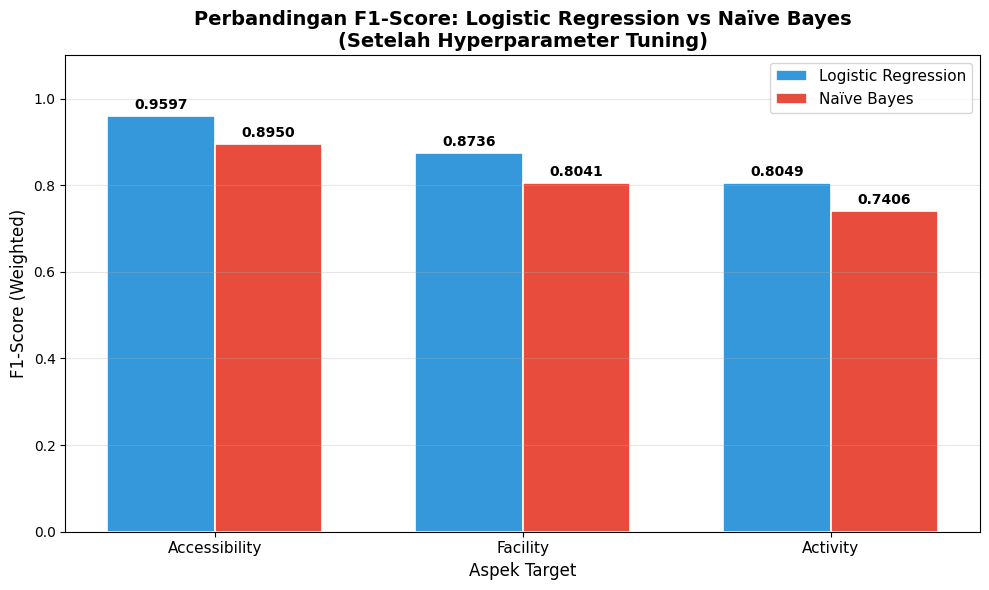

Grafik perbandingan disimpan sebagai 'perbandingan_f1score.png'


In [30]:
aspects = target_cols
lr_f1_scores = [tuning_results[col]['lr_f1'] for col in target_cols]
nb_f1_scores = [tuning_results[col]['nb_f1'] for col in target_cols]

x = np.arange(len(aspects))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lr_f1_scores, width, label='Logistic Regression', color='#3498db', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, nb_f1_scores, width, label='Naïve Bayes', color='#e74c3c', edgecolor='white', linewidth=1.2)

ax.set_xlabel('Aspek Target', fontsize=12)
ax.set_ylabel('F1-Score (Weighted)', fontsize=12)
ax.set_title('Perbandingan F1-Score: Logistic Regression vs Naïve Bayes\n(Setelah Hyperparameter Tuning)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in aspects], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('perbandingan_f1score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik perbandingan disimpan sebagai 'perbandingan_f1score.png'")

In [31]:
print("=" * 60)
print("PENENTUAN MODEL TERBAIK PER ASPEK")
print("=" * 60)

for col in target_cols:
    lr_f1 = tuning_results[col]['lr_f1']
    nb_f1 = tuning_results[col]['nb_f1']
    
    print(f"\n--- {col.upper()} ---")
    print(f"  Logistic Regression : F1={lr_f1:.4f} | Acc={tuning_results[col]['lr_acc']:.4f} | Params={tuning_results[col]['lr_params']}")
    print(f"  Naïve Bayes         : F1={nb_f1:.4f} | Acc={tuning_results[col]['nb_acc']:.4f} | Params={tuning_results[col]['nb_params']}")
    
    if lr_f1 > nb_f1:
        print(f"  >>> MODEL TERBAIK: Logistic Regression (F1 lebih tinggi {lr_f1 - nb_f1:.4f})")
    elif nb_f1 > lr_f1:
        print(f"  >>> MODEL TERBAIK: Naïve Bayes (F1 lebih tinggi {nb_f1 - lr_f1:.4f})")
    else:
        print(f"  >>> SERI: Kedua model memiliki F1-Score yang sama")

PENENTUAN MODEL TERBAIK PER ASPEK

--- ACCESSIBILITY ---
  Logistic Regression : F1=0.9597 | Acc=0.9602 | Params={'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
  Naïve Bayes         : F1=0.8950 | Acc=0.8963 | Params={'alpha': 0.01}
  >>> MODEL TERBAIK: Logistic Regression (F1 lebih tinggi 0.0647)

--- FACILITY ---
  Logistic Regression : F1=0.8736 | Acc=0.8763 | Params={'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
  Naïve Bayes         : F1=0.8041 | Acc=0.8073 | Params={'alpha': 0.01}
  >>> MODEL TERBAIK: Logistic Regression (F1 lebih tinggi 0.0695)

--- ACTIVITY ---
  Logistic Regression : F1=0.8049 | Acc=0.8057 | Params={'C': 10, 'penalty': 'l2', 'solver': 'saga'}
  Naïve Bayes         : F1=0.7406 | Acc=0.7481 | Params={'alpha': 0.01}
  >>> MODEL TERBAIK: Logistic Regression (F1 lebih tinggi 0.0644)


In [32]:
print("=" * 60)
print("RINGKASAN MODELING FASE 1")
print("=" * 60)

avg_lr_f1 = np.mean([tuning_results[col]['lr_f1'] for col in target_cols])
avg_nb_f1 = np.mean([tuning_results[col]['nb_f1'] for col in target_cols])

print(f"\nRata-rata F1-Score (Tuned):")
print(f"  Logistic Regression: {avg_lr_f1:.4f}")
print(f"  Naïve Bayes        : {avg_nb_f1:.4f}")

if avg_lr_f1 > avg_nb_f1:
    print(f"\nSecara keseluruhan, Logistic Regression memberikan performa yang lebih baik.")
elif avg_nb_f1 > avg_lr_f1:
    print(f"\nSecara keseluruhan, Naïve Bayes memberikan performa yang lebih baik.")
else:
    print(f"\nSecara keseluruhan, kedua model memberikan performa yang setara.")

print(f"\nFile output:")
print(f"  - confusion_matrix.png")
print(f"  - perbandingan_f1score.png")

RINGKASAN MODELING FASE 1

Rata-rata F1-Score (Tuned):
  Logistic Regression: 0.8794
  Naïve Bayes        : 0.8132

Secara keseluruhan, Logistic Regression memberikan performa yang lebih baik.

File output:
  - confusion_matrix.png
  - perbandingan_f1score.png


---
---
# Modeling Fase 2: Unsupervised Learning (K-Means Clustering)

Pada fase ini, model klasifikasi terbaik dari Fase 1 digunakan untuk memprediksi label sentimen pada seluruh dataset. Kemudian, dilakukan **agregasi rasio sentimen per lokasi wisata** dan **K-Means Clustering** untuk mengelompokkan destinasi wisata berdasarkan profil sentimennya.

Proses:
1. Prediksi sentimen menggunakan model terbaik
2. Agregasi persentase sentimen per lokasi
3. K-Means Clustering dengan Elbow Method & Silhouette Score
4. Analisis hasil klaster

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

### 1. Prediksi Sentimen dengan Model Terbaik

In [34]:
final_models = {}

for col in target_cols:
    lr_f1 = tuning_results[col]['lr_f1']
    nb_f1 = tuning_results[col]['nb_f1']
    
    if lr_f1 >= nb_f1:
        final_models[col] = {
            'model': best_models[col]['lr'],
            'name': 'Logistic Regression',
            'f1': lr_f1
        }
    else:
        final_models[col] = {
            'model': best_models[col]['nb'],
            'name': 'Naïve Bayes',
            'f1': nb_f1
        }

print("--- Model Terbaik yang Digunakan ---")
for col in target_cols:
    print(f"  {col}: {final_models[col]['name']} (F1={final_models[col]['f1']:.4f})")

--- Model Terbaik yang Digunakan ---
  accessibility: Logistic Regression (F1=0.9597)
  facility: Logistic Regression (F1=0.8736)
  activity: Logistic Regression (F1=0.8049)


In [35]:
df_predicted = df_transformed.copy()

for col in target_cols:
    model = final_models[col]['model']
    y_pred = model.predict(X_tfidf)
    pred_labels = label_encoders[col].inverse_transform(y_pred)
    df_predicted[f'{col}_pred'] = pred_labels

print("--- Hasil Prediksi Sentimen ---")
for col in target_cols:
    print(f"\n{col} (prediksi vs aktual):")
    print(f"  Prediksi : {df_predicted[f'{col}_pred'].value_counts().to_dict()}")
    print(f"  Aktual   : {df_predicted[col].value_counts().to_dict()}")

print(f"\nContoh data:")
print(df_predicted[['location', 'text_clean'] + [f'{c}_pred' for c in target_cols]].head(10).to_string())

--- Hasil Prediksi Sentimen ---

accessibility (prediksi vs aktual):
  Prediksi : {'neutral': 9811, 'negative': 1145, 'positive': 654}
  Aktual   : {'neutral': 10187, 'negative': 862, 'positive': 561}

facility (prediksi vs aktual):
  Prediksi : {'neutral': 7452, 'positive': 2633, 'negative': 1525}
  Aktual   : {'neutral': 8095, 'positive': 2318, 'negative': 1197}

activity (prediksi vs aktual):
  Prediksi : {'positive': 6872, 'neutral': 4025, 'negative': 713}
  Aktual   : {'positive': 7153, 'neutral': 4074, 'negative': 383}

Contoh data:
       location                                                                                                                                                                                                                                                                                                                                                                                                                                                        

### 2. Agregasi Persentase Sentimen per Lokasi

In [36]:
sentiment_labels = ['positive', 'negative', 'neutral']
agg_data = []

for location in df_predicted['location'].unique():
    loc_data = df_predicted[df_predicted['location'] == location]
    total = len(loc_data)
    row = {'location': location, 'total_reviews': total}
    
    for col in target_cols:
        for sentiment in sentiment_labels:
            count = (loc_data[f'{col}_pred'] == sentiment).sum()
            row[f'{col}_{sentiment}_pct'] = count / total * 100
    
    agg_data.append(row)

df_location = pd.DataFrame(agg_data)
df_location = df_location.sort_values('total_reviews', ascending=False).reset_index(drop=True)

print(f"Jumlah lokasi wisata unik: {len(df_location)}")
print(f"\nKolom fitur agregasi: {[c for c in df_location.columns if '_pct' in c]}")
print(f"\nData agregasi per lokasi:")
print(df_location.to_string())

Jumlah lokasi wisata unik: 25

Kolom fitur agregasi: ['accessibility_positive_pct', 'accessibility_negative_pct', 'accessibility_neutral_pct', 'facility_positive_pct', 'facility_negative_pct', 'facility_neutral_pct', 'activity_positive_pct', 'activity_negative_pct', 'activity_neutral_pct']

Data agregasi per lokasi:
                          location  total_reviews  accessibility_positive_pct  accessibility_negative_pct  accessibility_neutral_pct  facility_positive_pct  facility_negative_pct  facility_neutral_pct  activity_positive_pct  activity_negative_pct  activity_neutral_pct
0                      Sarae Hills            952                    5.777311                    7.983193                  86.239496              21.638655              15.651261             62.710084              63.130252               9.348739             27.521008
1             Gunung Putri Lembang            943                   12.937434                    4.453871                  82.608696            

In [37]:
feature_cols = [c for c in df_location.columns if '_pct' in c]
X_cluster = df_location[feature_cols].values

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print(f"Dimensi data untuk clustering: {X_cluster_scaled.shape}")
print(f"Fitur yang digunakan ({len(feature_cols)}):")
for f in feature_cols:
    print(f"  - {f}")

Dimensi data untuk clustering: (25, 9)
Fitur yang digunakan (9):
  - accessibility_positive_pct
  - accessibility_negative_pct
  - accessibility_neutral_pct
  - facility_positive_pct
  - facility_negative_pct
  - facility_neutral_pct
  - activity_positive_pct
  - activity_negative_pct
  - activity_neutral_pct


### 3. Elbow Method (WCSS/Inertia)

In [38]:
max_k = min(10, len(df_location) - 1)
K_range = range(2, max_k + 1)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_cluster_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"K={k} | Inertia={kmeans.inertia_:.2f} | Silhouette Score={sil_score:.4f}")

best_k_silhouette = list(K_range)[np.argmax(silhouette_scores)]
best_sil_score = max(silhouette_scores)
print(f"\nK optimal berdasarkan Silhouette Score: K={best_k_silhouette} (score={best_sil_score:.4f})")

K=2 | Inertia=159.43 | Silhouette Score=0.2688
K=3 | Inertia=127.94 | Silhouette Score=0.2510
K=4 | Inertia=101.18 | Silhouette Score=0.1932
K=5 | Inertia=85.47 | Silhouette Score=0.1729
K=6 | Inertia=73.61 | Silhouette Score=0.1666
K=7 | Inertia=62.63 | Silhouette Score=0.1930
K=8 | Inertia=55.67 | Silhouette Score=0.1743
K=9 | Inertia=45.53 | Silhouette Score=0.1800
K=10 | Inertia=38.55 | Silhouette Score=0.1867

K optimal berdasarkan Silhouette Score: K=2 (score=0.2688)


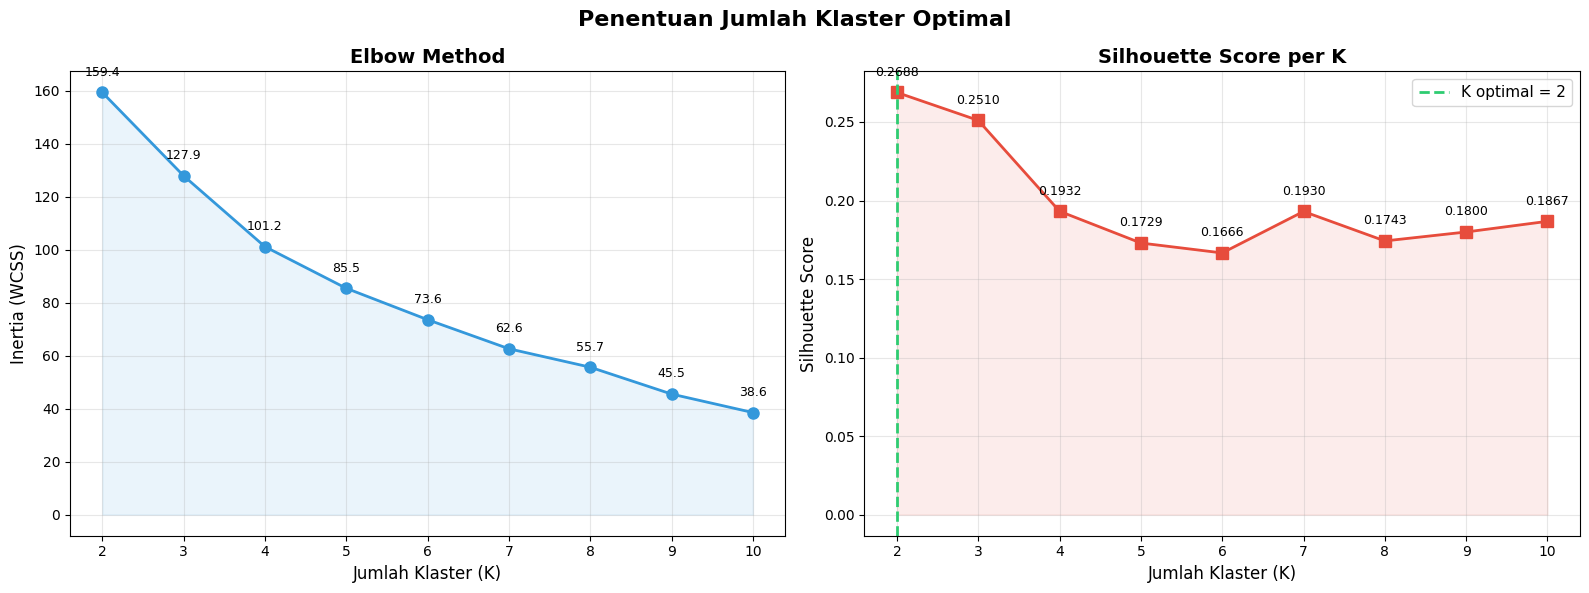

Grafik Elbow & Silhouette disimpan sebagai 'elbow_silhouette.png'


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8, color='#3498db')
axes[0].fill_between(list(K_range), inertias, alpha=0.1, color='#3498db')
axes[0].set_xlabel('Jumlah Klaster (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(K_range))
axes[0].grid(alpha=0.3)
for i, (k, inertia) in enumerate(zip(K_range, inertias)):
    axes[0].annotate(f'{inertia:.1f}', (k, inertia), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9)

axes[1].plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=8, color='#e74c3c')
axes[1].fill_between(list(K_range), silhouette_scores, alpha=0.1, color='#e74c3c')
axes[1].axvline(x=best_k_silhouette, color='#2ecc71', linestyle='--', linewidth=2, label=f'K optimal = {best_k_silhouette}')
axes[1].set_xlabel('Jumlah Klaster (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score per K', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(K_range))
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
for i, (k, score) in enumerate(zip(K_range, silhouette_scores)):
    axes[1].annotate(f'{score:.4f}', (k, score), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9)

plt.suptitle('Penentuan Jumlah Klaster Optimal', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik Elbow & Silhouette disimpan sebagai 'elbow_silhouette.png'")

### 4. K-Means Clustering dengan K Optimal

In [40]:
optimal_k = best_k_silhouette
print(f"Menggunakan K = {optimal_k}\n")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_location['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

print(f"Silhouette Score: {silhouette_score(X_cluster_scaled, df_location['cluster']):.4f}")
print(f"Inertia: {kmeans_final.inertia_:.2f}")

print(f"\nDistribusi Klaster:")
for cluster_id in sorted(df_location['cluster'].unique()):
    count = (df_location['cluster'] == cluster_id).sum()
    print(f"  Klaster {cluster_id}: {count} lokasi")

Menggunakan K = 2

Silhouette Score: 0.2688
Inertia: 159.43

Distribusi Klaster:
  Klaster 0: 7 lokasi
  Klaster 1: 18 lokasi


In [41]:
print("--- Anggota Setiap Klaster ---")
for cluster_id in sorted(df_location['cluster'].unique()):
    print(f"\nKLASTER {cluster_id}:")
    cluster_members = df_location[df_location['cluster'] == cluster_id]
    for _, row in cluster_members.iterrows():
        print(f"  - {row['location']} ({row['total_reviews']} ulasan)")

--- Anggota Setiap Klaster ---

KLASTER 0:
  - Sarae Hills (952 ulasan)
  - Curug Maribaya (937 ulasan)
  - Floating Market Lembang (911 ulasan)
  - Terminal Wisata Grafika Cikole (900 ulasan)
  - Orchid Forest Cikole (671 ulasan)
  - Taman Lembah DEWATA (505 ulasan)
  - Kebun Begonia Lembang (358 ulasan)

KLASTER 1:
  - Gunung Putri Lembang (943 ulasan)
  - Gunung Tangkuban Parahu (925 ulasan)
  - Stone Garden (914 ulasan)
  - Curug Tilu Leuwi Opat (634 ulasan)
  - Ciwangun Indah Camp (CIC) (489 ulasan)
  - Sanghyang Heuleut (445 ulasan)
  - Curug Cimahi / Curug Pelangi (401 ulasan)
  - Curug Layung Camp Situ Lembang (324 ulasan)
  - Sanghyang Kenit (323 ulasan)
  - Bukit Senyum (271 ulasan)
  - Curug Malela (162 ulasan)
  - Curug Sawer Cililin (149 ulasan)
  - Taman Hutan Jayagiri Lembang (148 ulasan)
  - Situ Ciburuy (120 ulasan)
  - Curug Halimun (52 ulasan)
  - Curug Panganten (44 ulasan)
  - Gunung Hawu (29 ulasan)
  - Sirtwo Island Saguling (3 ulasan)


In [42]:
print("--- Profil Sentimen Rata-rata per Klaster ---\n")

for cluster_id in sorted(df_location['cluster'].unique()):
    cluster_data = df_location[df_location['cluster'] == cluster_id]
    print(f"KLASTER {cluster_id} ({len(cluster_data)} lokasi):")
    
    for col in target_cols:
        pos = cluster_data[f'{col}_positive_pct'].mean()
        neg = cluster_data[f'{col}_negative_pct'].mean()
        neu = cluster_data[f'{col}_neutral_pct'].mean()
        print(f"  {col:15s} -> Positif: {pos:6.2f}% | Negatif: {neg:6.2f}% | Netral: {neu:6.2f}%")
    print()

--- Profil Sentimen Rata-rata per Klaster ---

KLASTER 0 (7 lokasi):
  accessibility   -> Positif:   2.92% | Negatif:   5.27% | Netral:  91.82%
  facility        -> Positif:  31.67% | Negatif:  14.24% | Netral:  54.09%
  activity        -> Positif:  69.91% | Negatif:   8.18% | Netral:  21.91%

KLASTER 1 (18 lokasi):
  accessibility   -> Positif:   6.64% | Negatif:  15.10% | Netral:  78.26%
  facility        -> Positif:  12.72% | Negatif:   9.43% | Netral:  77.84%
  activity        -> Positif:  51.22% | Negatif:   3.73% | Netral:  45.05%



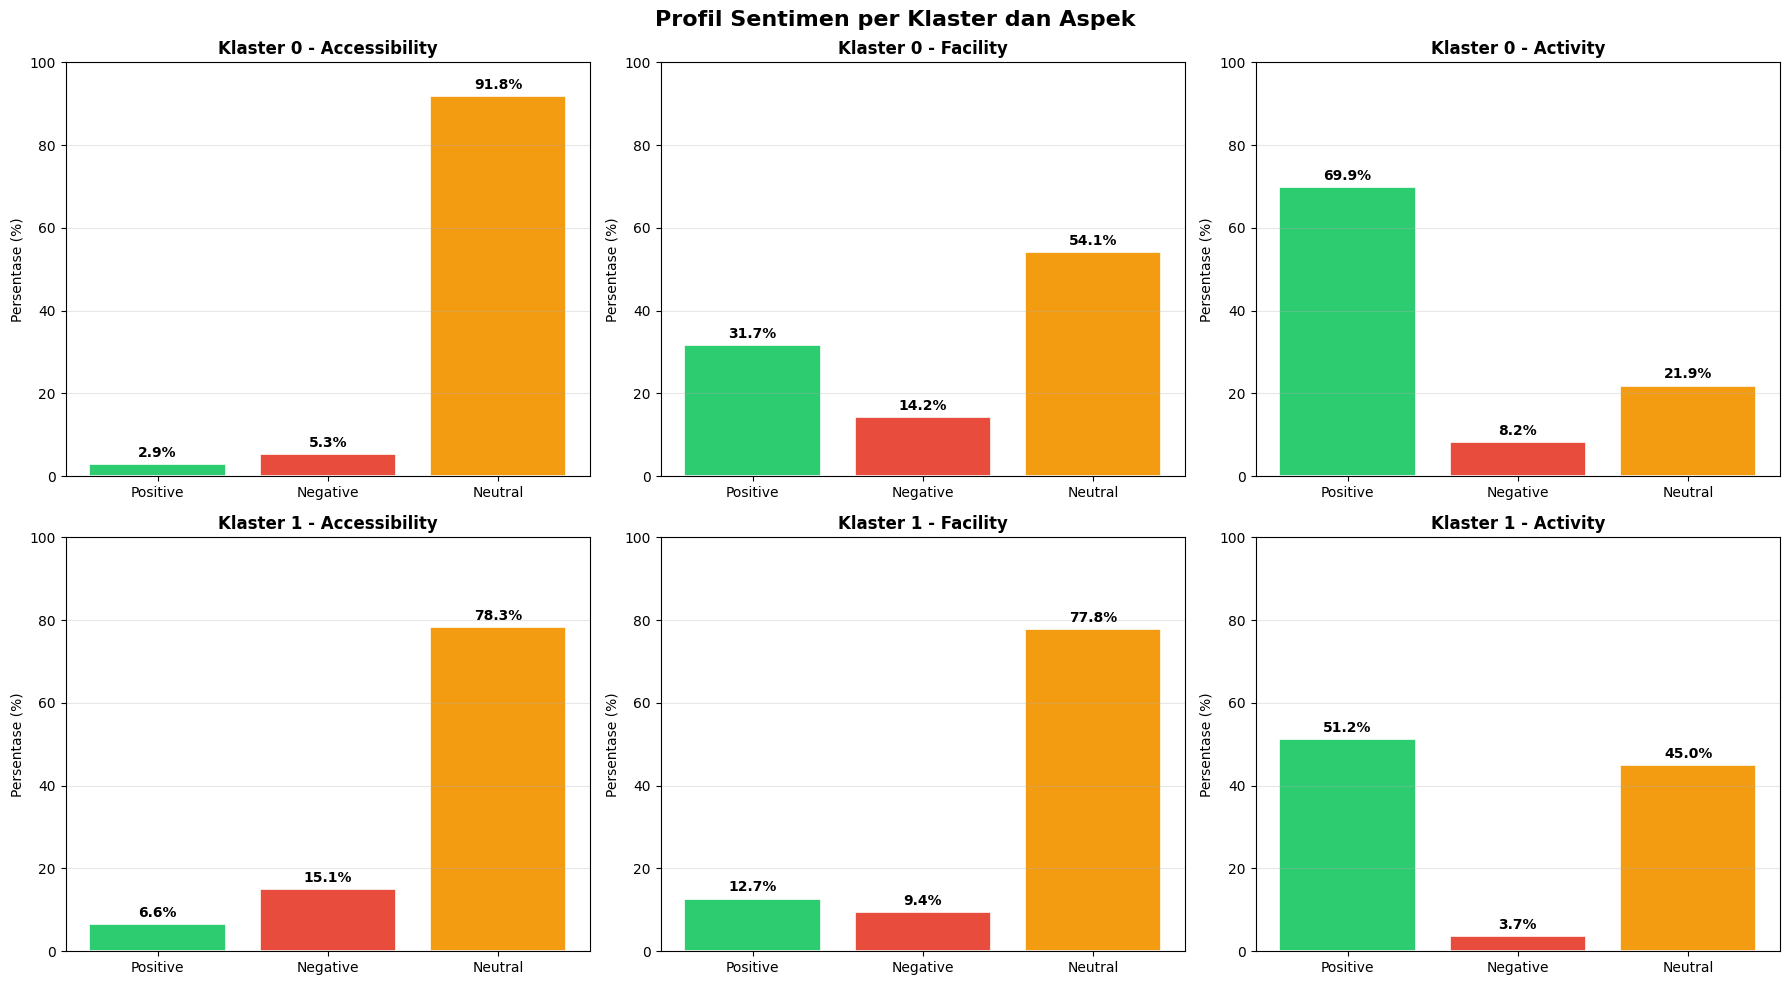

Grafik profil klaster disimpan sebagai 'profil_klaster.png'


In [43]:
n_clusters = optimal_k
fig, axes = plt.subplots(n_clusters, 3, figsize=(18, 5 * n_clusters))

if n_clusters == 1:
    axes = axes.reshape(1, -1)

cluster_colors = ['#2ecc71', '#e74c3c', '#f39c12']
bar_labels = ['Positive', 'Negative', 'Neutral']

for cluster_id in range(n_clusters):
    cluster_data = df_location[df_location['cluster'] == cluster_id]
    
    for j, col in enumerate(target_cols):
        pos_mean = cluster_data[f'{col}_positive_pct'].mean()
        neg_mean = cluster_data[f'{col}_negative_pct'].mean()
        neu_mean = cluster_data[f'{col}_neutral_pct'].mean()
        
        values = [pos_mean, neg_mean, neu_mean]
        bars = axes[cluster_id][j].bar(bar_labels, values, color=cluster_colors, edgecolor='white', linewidth=1.2)
        axes[cluster_id][j].set_title(f'Klaster {cluster_id} - {col.capitalize()}', fontsize=12, fontweight='bold')
        axes[cluster_id][j].set_ylabel('Persentase (%)')
        axes[cluster_id][j].set_ylim(0, 100)
        axes[cluster_id][j].grid(axis='y', alpha=0.3)
        
        for bar, val in zip(bars, values):
            axes[cluster_id][j].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Profil Sentimen per Klaster dan Aspek', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('profil_klaster.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik profil klaster disimpan sebagai 'profil_klaster.png'")

In [44]:
df_location.to_csv('Output/lokasi_klaster.csv', index=False)

print("=" * 60)
print("RINGKASAN MODELING FASE 2")
print("=" * 60)

print(f"\nJumlah lokasi wisata: {len(df_location)}")
print(f"Jumlah fitur agregasi: {len(feature_cols)}")
print(f"Jumlah klaster optimal (K): {optimal_k}")
print(f"Silhouette Score: {silhouette_score(X_cluster_scaled, df_location['cluster']):.4f}")

print(f"\nDistribusi Klaster:")
for cluster_id in sorted(df_location['cluster'].unique()):
    members = df_location[df_location['cluster'] == cluster_id]['location'].tolist()
    print(f"  Klaster {cluster_id} ({len(members)} lokasi): {', '.join(members)}")

print(f"\nFile output:")
print(f"  - Output/lokasi_klaster.csv")
print(f"  - elbow_silhouette.png")
print(f"  - profil_klaster.png")

RINGKASAN MODELING FASE 2

Jumlah lokasi wisata: 25
Jumlah fitur agregasi: 9
Jumlah klaster optimal (K): 2
Silhouette Score: 0.2688

Distribusi Klaster:
  Klaster 0 (7 lokasi): Sarae Hills, Curug Maribaya, Floating Market Lembang, Terminal Wisata Grafika Cikole, Orchid Forest Cikole, Taman Lembah DEWATA, Kebun Begonia Lembang
  Klaster 1 (18 lokasi): Gunung Putri Lembang, Gunung Tangkuban Parahu, Stone Garden, Curug Tilu Leuwi Opat, Ciwangun Indah Camp (CIC), Sanghyang Heuleut, Curug Cimahi / Curug Pelangi, Curug Layung Camp Situ Lembang, Sanghyang Kenit, Bukit Senyum, Curug Malela, Curug Sawer Cililin, Taman Hutan Jayagiri Lembang, Situ Ciburuy, Curug Halimun, Curug Panganten, Gunung Hawu, Sirtwo Island Saguling

File output:
  - Output/lokasi_klaster.csv
  - elbow_silhouette.png
  - profil_klaster.png
